In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mlt
import seaborn as sns
mlt.style.use('fivethirtyeight')
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls



In [4]:
matches = pd.read_csv(r"C:\Users\vishnu priya\Downloads\matches.csv")
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [5]:
deliveries = pd.read_csv(r"C:\Users\vishnu priya\Downloads\deliveries.csv")
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [8]:
###Cleaning & Trnsformation

In [19]:
matches.drop(['umpire3'], axis = 1, inplace = True)

In [82]:
deliveries.fillna(0, inplace = True)

In [86]:
matches['team1'].unique()

array(['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR', 'DD', 'GL', 'KXIP', 'SRM',
       'RPS', 'KTK', 'PW'], dtype=object)

In [84]:
matches.replace(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants']
      ,['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR','DD', 'GL', 'KXIP', 'SRM', 'RPS', 'KTK', 'PW', 'RPS'],inplace=True)

deliveries.replace(['Sunrisers Hyderabad', 'Mumbai Indians', 'Gujarat Lions',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Kings XI Punjab',
       'Chennai Super Kings', 'Rajasthan Royals', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants']
      ,['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR','DD', 'GL', 'KXIP', 'SRM', 'RPS', 'KTK', 'PW', 'RPS'],inplace=True)


###Basic Analysis

In [85]:
print('Total Matches Played', matches.shape[0])
print('\nVenues Played at:', matches['city'].unique())
print('\nTeams:', matches['team1'].unique())

Total Matches Played 636

Venues Played at: ['Hyderabad' 'Pune' 'Rajkot' 'Indore' 'Bangalore' 'Mumbai' 'Kolkata'
 'Delhi' 'Chandigarh' 'Kanpur' 'Jaipur' 'Chennai' 'Cape Town'
 'Port Elizabeth' 'Durban' 'Centurion' 'East London' 'Johannesburg'
 'Kimberley' 'Bloemfontein' 'Ahmedabad' 'Cuttack' 'Nagpur' 'Dharamsala'
 'Kochi' 'Visakhapatnam' 'Raipur' 'Ranchi' 'Abu Dhabi' 'Sharjah' nan]

Teams: ['MI' 'KKR' 'RCB' 'DC' 'CSK' 'RR' 'DD' 'GL' 'KXIP' 'SRM' 'RPS' 'KTK' 'PW']


In [132]:
print('\nTotal Venues Played at:', matches['city'].nunique())
print('\nTotal Umpires:', matches['umpire1'].nunique())


Total Venues Played at: 30

Total Umpires: 44


In [22]:
print((matches['player_of_match'].value_counts()).idxmax(),': has the man the match')

CH Gayle : has the man the match


In [23]:
print((matches['winner'].value_counts()).idxmax(),': has the highest number of match wins')

KKR : has the highest number of match wins


In [17]:
df = matches.iloc[[matches['win_by_runs'].idxmax()]]
df[['season', 'team1', 'team2', 'winner', 'win_by_runs']]

,season,team1,team2,winner,win_by_runs
43,2017,Mumbai Indians,Delhi Daredevils,Mumbai Indians,146


In [18]:
df = matches.iloc[[matches['win_by_wickets'].idxmax()]]
df[['season', 'team1', 'team2', 'winner', 'win_by_wickets']]

,season,team1,team2,winner,win_by_wickets
2,2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,10


###Toss Decision

In [34]:
matches['toss_decision'].value_counts().sum()

np.int64(636)

In [35]:
print('Toss Decisions in %\n', ((matches['toss_decision']).value_counts(normalize = True)))

Toss Decisions in %
 toss_decision
field    0.570755
bat      0.429245
Name: proportion, dtype: float64


###Toss Decisions Across Seasons

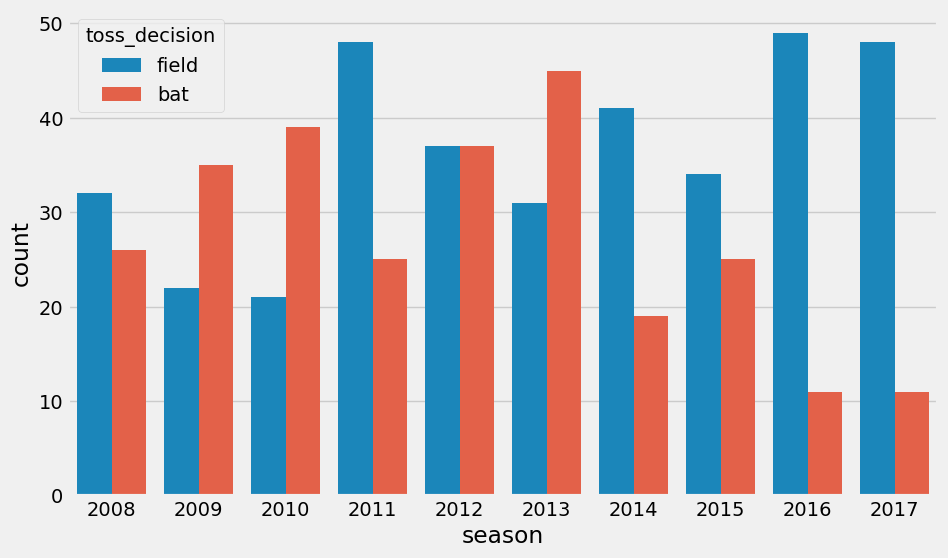

In [41]:
mlt.subplots(figsize = (10, 6))
sns.countplot(x = 'season', hue = 'toss_decision', data = matches)
mlt.show()

###Max toss winners

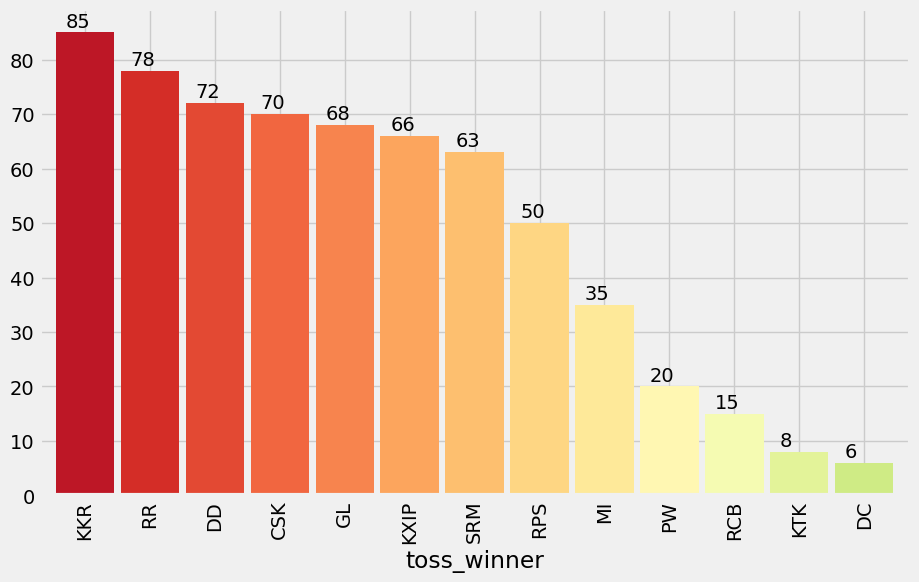

In [44]:
mlt.subplots(figsize = (10, 6))
ax = matches['toss_winner'].value_counts().plot.bar(width = 0.9, color = sns.color_palette('RdYlGn', 20))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.15, p.get_height() + 1))
mlt.show()

###Total Matches vs Wins for Teams

In [25]:
import warnings
warnings.filterwarnings('ignore')

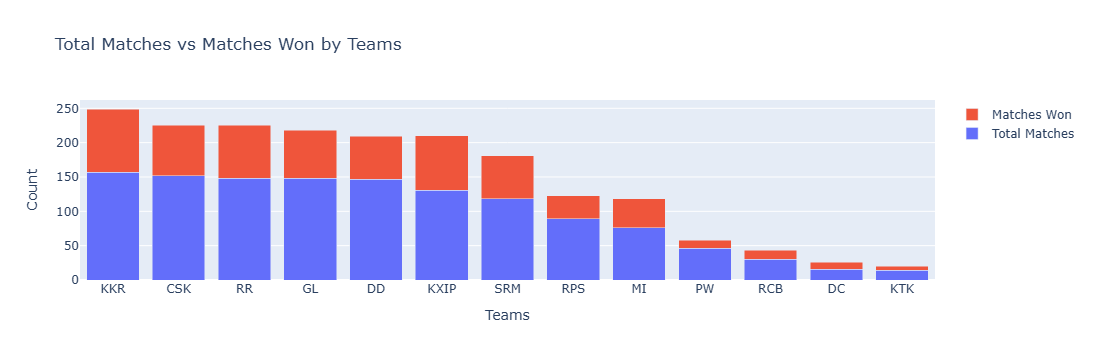

In [133]:
py.init_notebook_mode(connected = True)

matches_played_byteams = pd.concat([matches['team1'], matches['team2']])

matches_played_byteams = matches_played_byteams.value_counts().reset_index()
matches_played_byteams.columns = ['Team', 'Total Matches']

wins = matches['winner'].value_counts().reset_index()
wins.columns = ['Team', 'Wins']

matches_played_byteams = matches_played_byteams.merge(wins, on = 'Team', how = 'left')
matches_played_byteams['Wins'].fillna(0, inplace = True)

matches_played_byteams.set_index('Team', inplace = True)

trace1 = go.Bar(
    x = matches_played_byteams.index,
    y = matches_played_byteams['Total Matches'],
    name = 'Total Matches'
)
trace2 = go.Bar(
    x = matches_played_byteams.index,
    y = matches_played_byteams['Wins'],
    name = 'Matches Won' 
)
data = [trace1, trace2]
layout = go.Layout(
    title = 'Total Matches vs Matches Won by Teams',
    xaxis = dict(title = 'Teams'),
    yaxis = dict(title = 'Count'),
    barmode = 'stack'
)
fig = go.Figure(data  = data, layout = layout)
py.iplot(fig, filename = 'stacked-bar')



###Is Toss Winner also the Match Winner

In [9]:
matches.shape

(636, 18)

In [19]:
len(df)

1

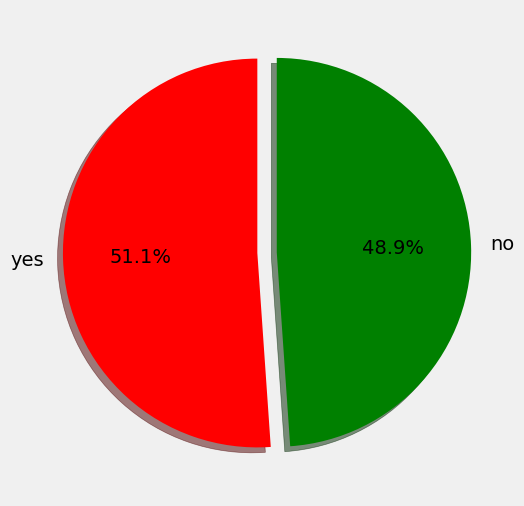

In [32]:
df = matches[matches['toss_winner'] == matches['winner']]
slices =[len(df), (636 - len(df))]
labels = ['yes', 'no']
mlt.pie(slices,
        labels = labels,
        startangle = 90,
        shadow = True,
        explode = (0, 0.1),
        autopct = '%1.1f%%',
        colors = ['r', 'g'])

fig = mlt.gcf()

fig.set_size_inches(6, 6)
mlt.show()

Matches played across each season

In [36]:
import warnings
warnings.filterwarnings('ignore')

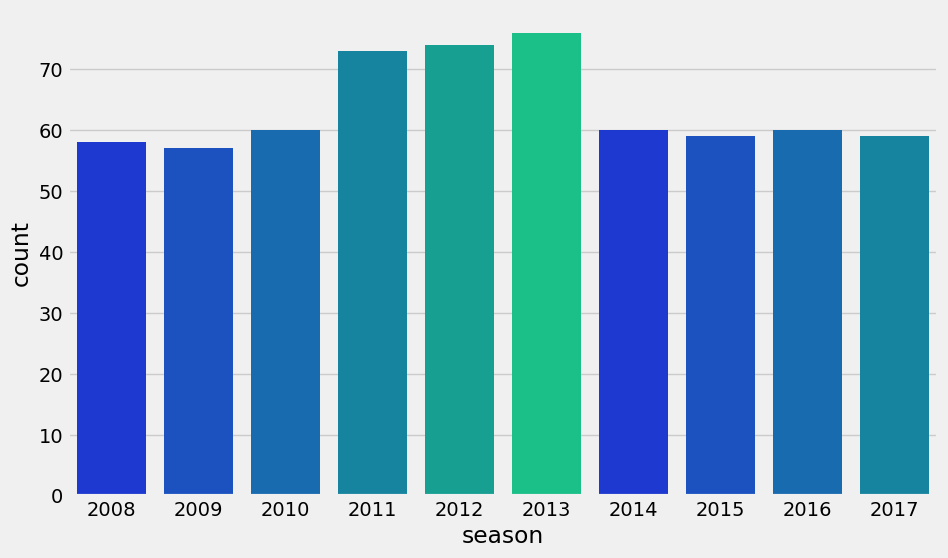

In [38]:
mlt.subplots(figsize = (10, 6))
sns.countplot(x = 'season', data = matches, palette = sns.color_palette('winter'))
mlt.show()


Runs Across the Seasons

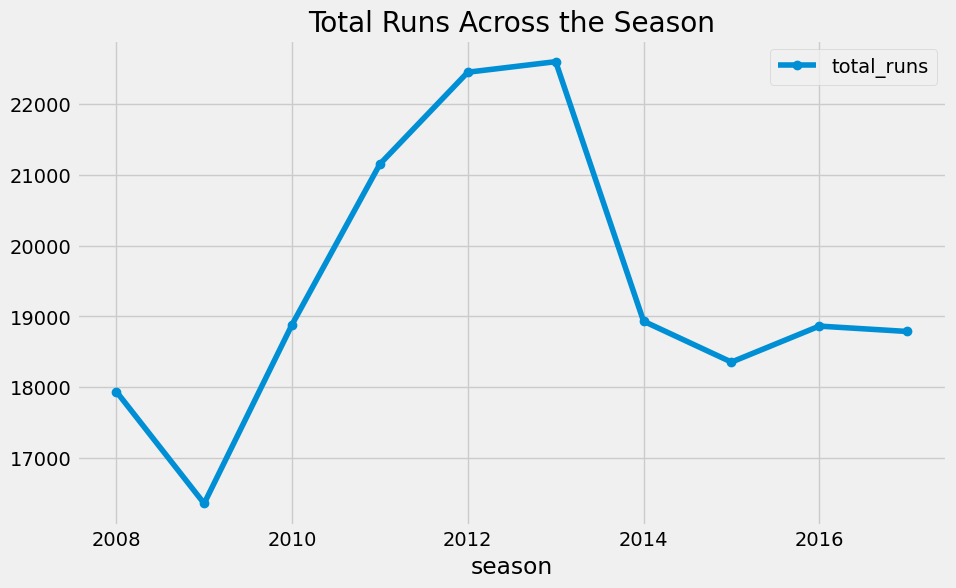

In [90]:
batsmen = matches[['id', 'season']].merge(deliveries,
         left_on = 'id',
         right_on = 'match_id',
         how = 'left').drop('id', axis = 1)
season = batsmen.groupby(['season'])['total_runs'].sum().reset_index()
season.set_index('season').plot(marker = 'o')
mlt.gcf().set_size_inches(10, 6)
mlt.title('Total Runs Across the Season')
mlt.show()


Average runs per match in each season

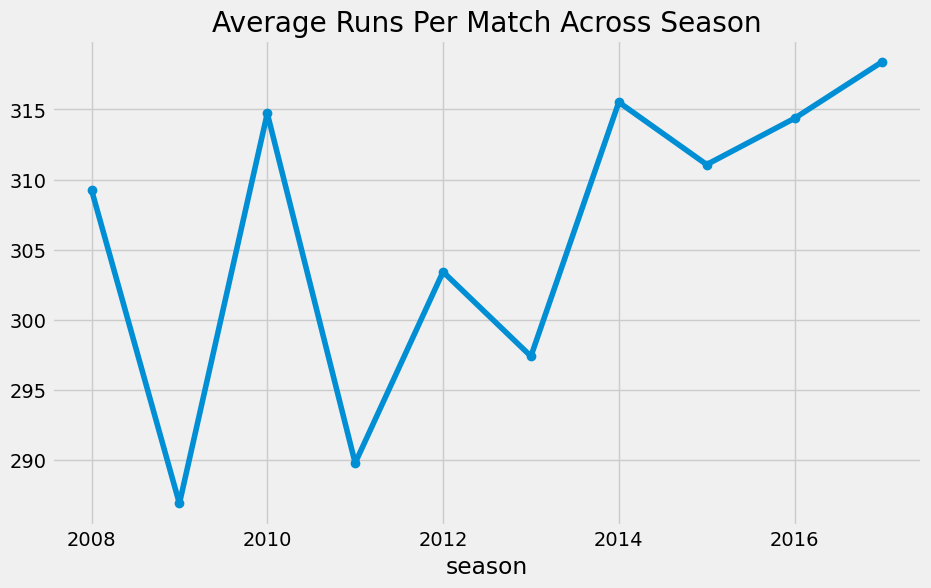

In [91]:
avgruns_each_season = matches.groupby(['season']).count().id.reset_index()
avgruns_each_season.rename(columns = {'id':'matches'}, inplace = True)
avgruns_each_season['total_runs'] = season['total_runs']
avgruns_each_season['average_runs_per_match'] = avgruns_each_season['total_runs'] / avgruns_each_season['matches']
avgruns_each_season.set_index('season')['average_runs_per_match'].plot(marker = 'o')
mlt.gcf().set_size_inches(10, 6)
mlt.title('Average Runs Per Match Across Season')
mlt.show()

Sixed and Fours Across the Season

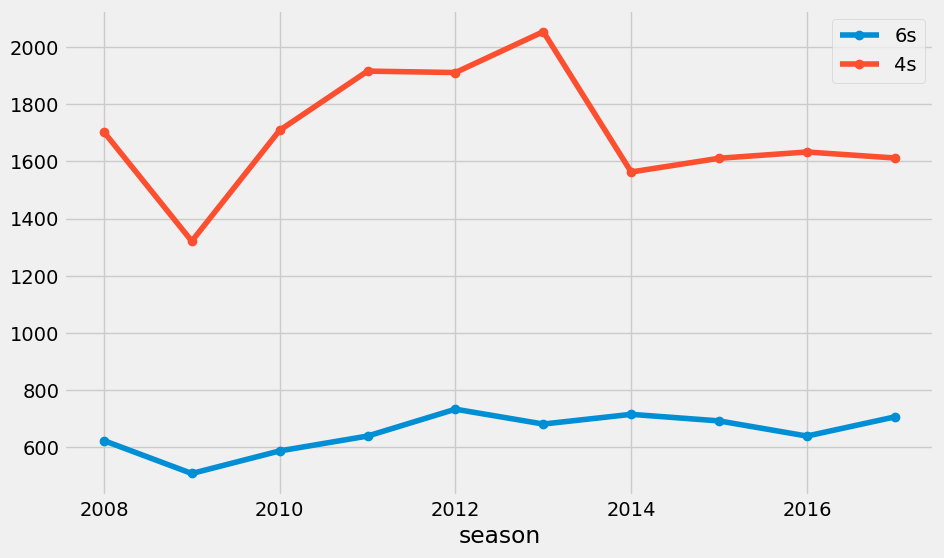

In [92]:
season_boundaries = batsmen.groupby('season')['batsman_runs'].agg(lambda x: (x ==6).sum()).reset_index()
a = batsmen.groupby('season')['batsman_runs'].agg(lambda x: (x ==4).sum()).reset_index()
season_boundaries = season_boundaries.merge(a, left_on = 'season', right_on = 'season', how = 'left')
season_boundaries = season_boundaries.rename(columns = {'batsman_runs_x': '6''s', 'batsman_runs_y': '4''s'})
season_boundaries.set_index('season')[['6''s', '4''s']].plot(marker = 'o')
fig = mlt.gcf()
fig.set_size_inches(10, 6)
mlt.show()

Runs Per Over by Teams Across Seasons

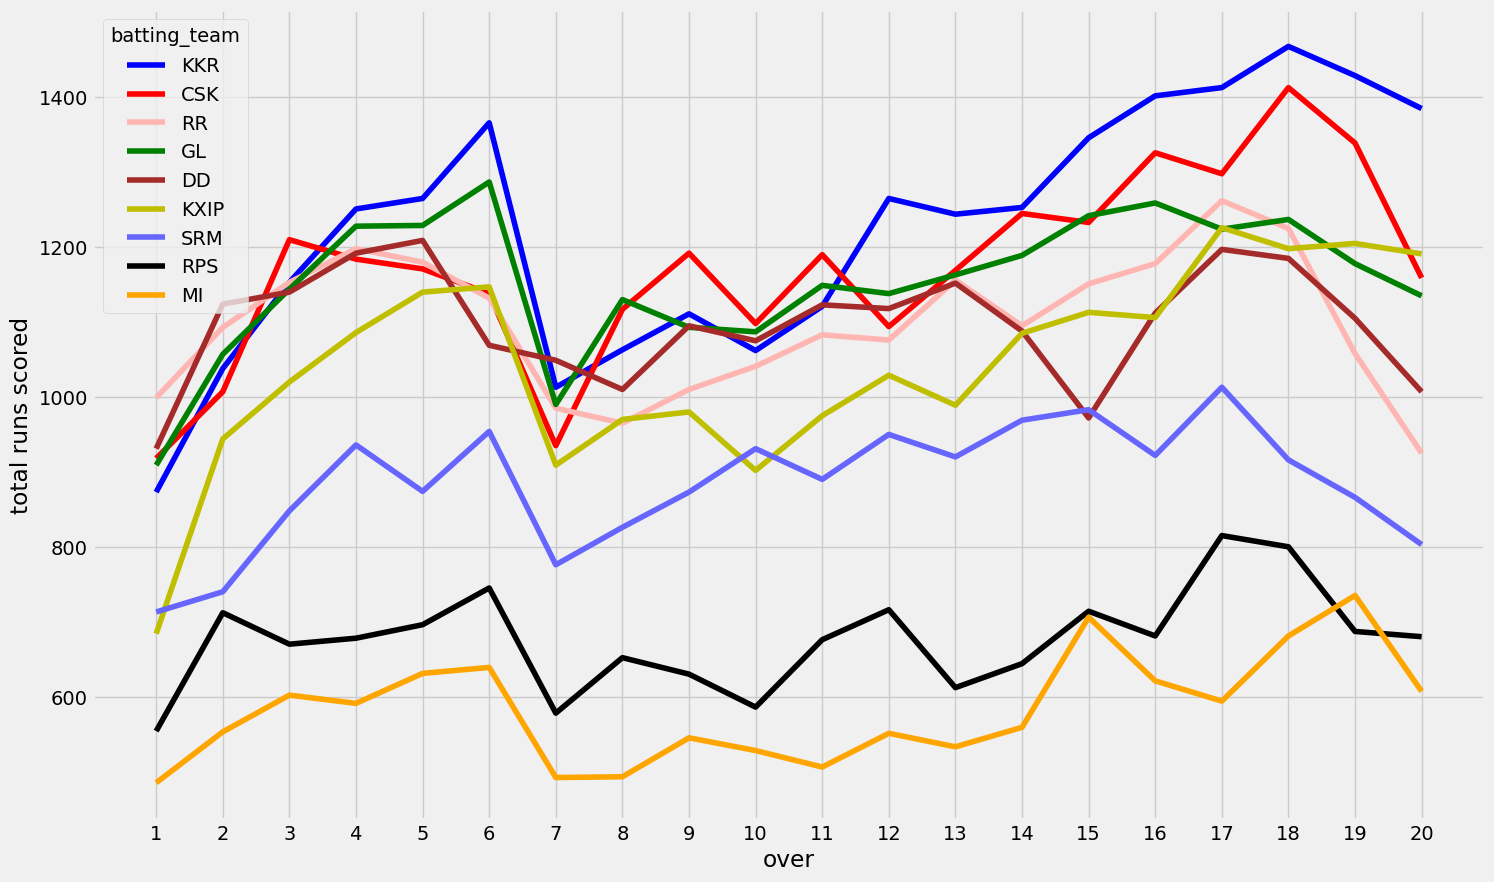

In [56]:
runs_per_over = deliveries.pivot_table(
    index = ['over'],
    columns = 'batting_team',
    values = 'total_runs',
    aggfunc = sum
)
            
runs_per_over[(matches_played_byteams[matches_played_byteams['Total Matches'] > 50].index)].plot(color = ['b', 'r', '#Ffb6b2', 'g', 'brown', 'y', '#6666ff', 'black', '#FFA500'])
x = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
mlt.xticks(x)
mlt.ylabel('total runs scored')
fig = mlt.gcf()
fig.set_size_inches(16, 10)
mlt.show()

Favorite Grounds

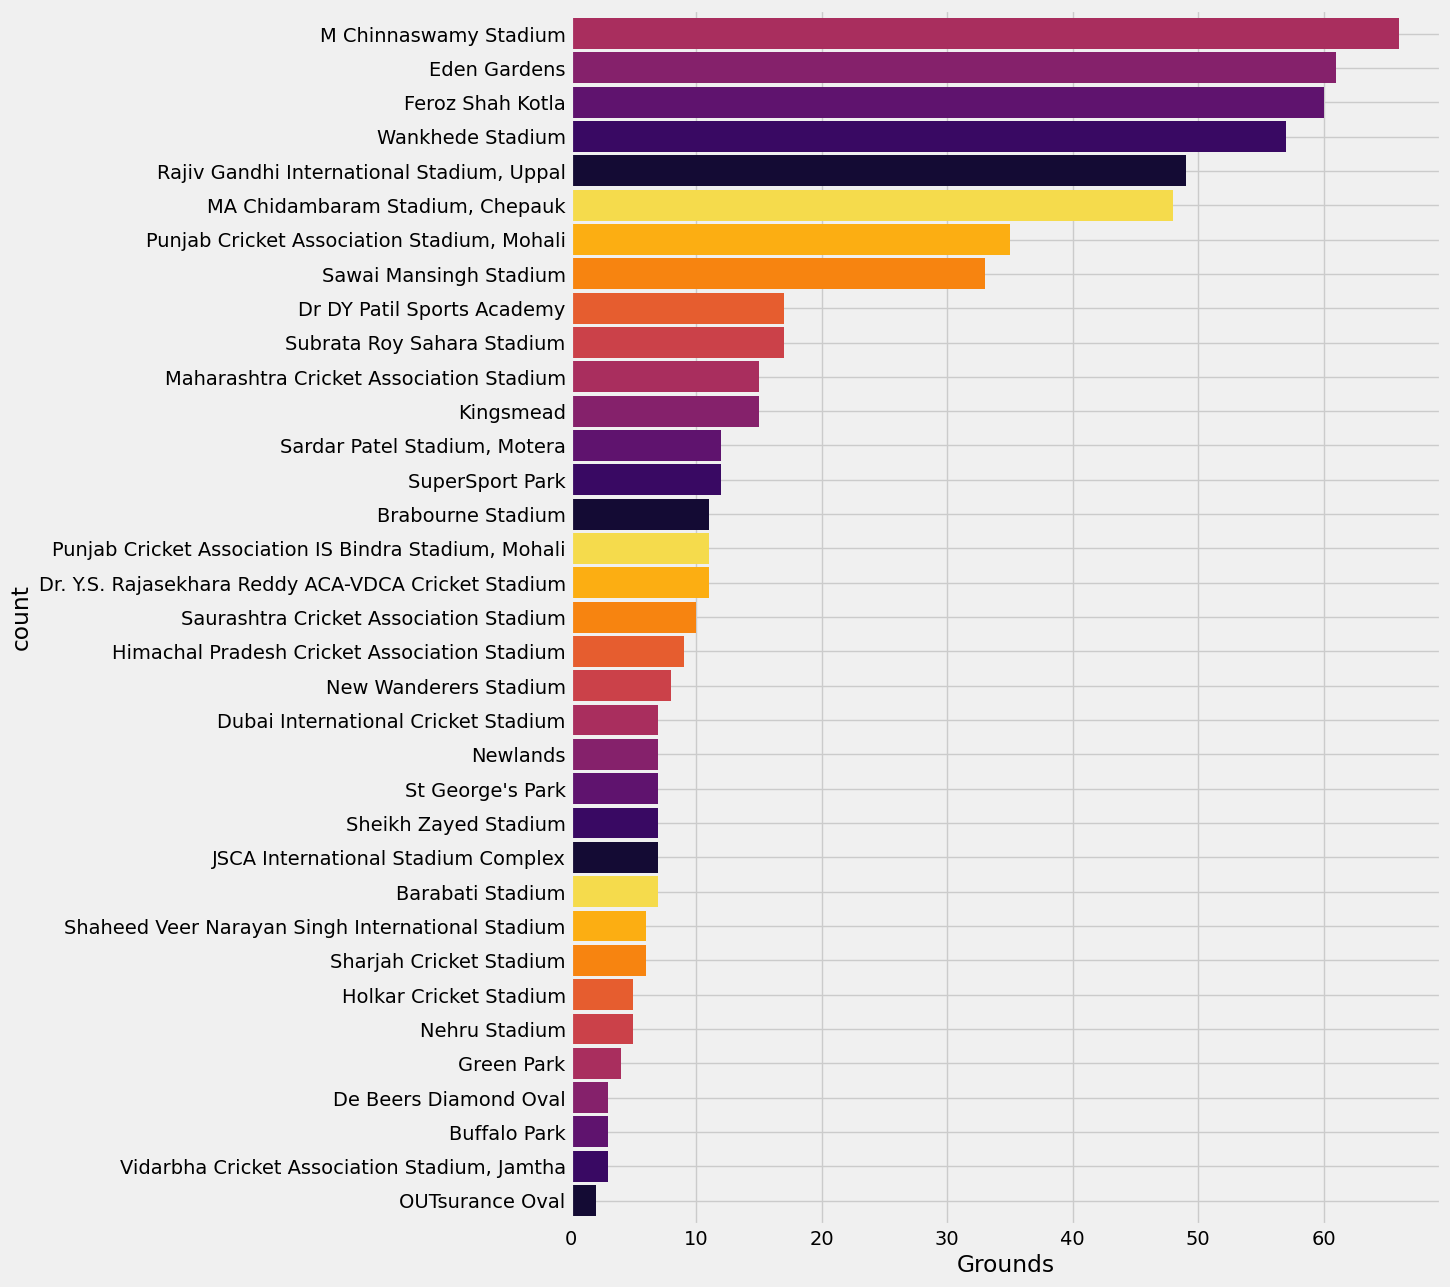

In [42]:
mlt.subplots(figsize = (10, 15)) 
ax = matches['venue'].value_counts().sort_values(ascending = True).plot.barh(width = 0.9, color = sns.color_palette('inferno', 10))
ax.set_xlabel('Grounds')
ax.set_ylabel('count')
mlt.show()

Maximum Man of Matches

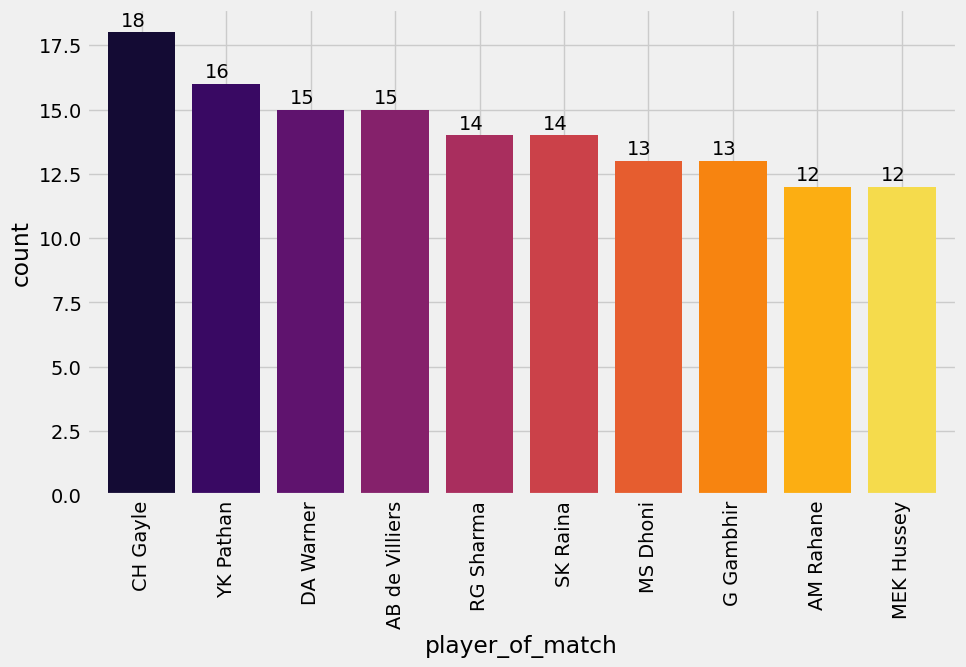

In [45]:
mlt.subplots(figsize = (10, 6))
ax = matches['player_of_match'].value_counts().head(10).plot.bar(width = 0.8, color = sns.color_palette('inferno', 10))
ax.set_xlabel('player_of_match')
ax.set_ylabel('count')
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.15, p.get_height() + 0.25))
mlt.show()
                                                                 

Winner by Year

In [27]:
import warnings
warnings.filterwarnings('ignore')

In [30]:
print('Winner By Years:\n')
for i in range(2008, 2017):
    df = ((matches[matches['season'] == i]).iloc[-1])
    print(df[[1, 10]].values)

Winner By Years:

[np.int64(2008) 'SRM']
[np.int64(2009) 'RPS']
[np.int64(2010) 'KXIP']
[np.int64(2011) 'KXIP']
[np.int64(2012) 'RR']
[np.int64(2013) 'KKR']
[np.int64(2014) 'RR']
[np.int64(2015) 'KKR']
[np.int64(2016) 'MI']


Super Over

In [31]:
print('\n Total Matches with Super Over:', deliveries[deliveries['is_super_over'] == 1].match_id.nunique())


 Total Matches with Super Over: 7


In [136]:
teams = ['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR', 'DD', 'GL', 'KXIP', 'SRM', 'RPS', 'KTK', 'PW']
play = deliveries[deliveries['is_super_over'] == 1].batting_team.unique()
play = list(play)

print("Teams who havent' ever played a super overs are: ", list(set(teams) - set(play)))


Teams who havent' ever played a super overs are:  ['PW', 'RPS', 'KTK', 'DC']


Favorite Umpires

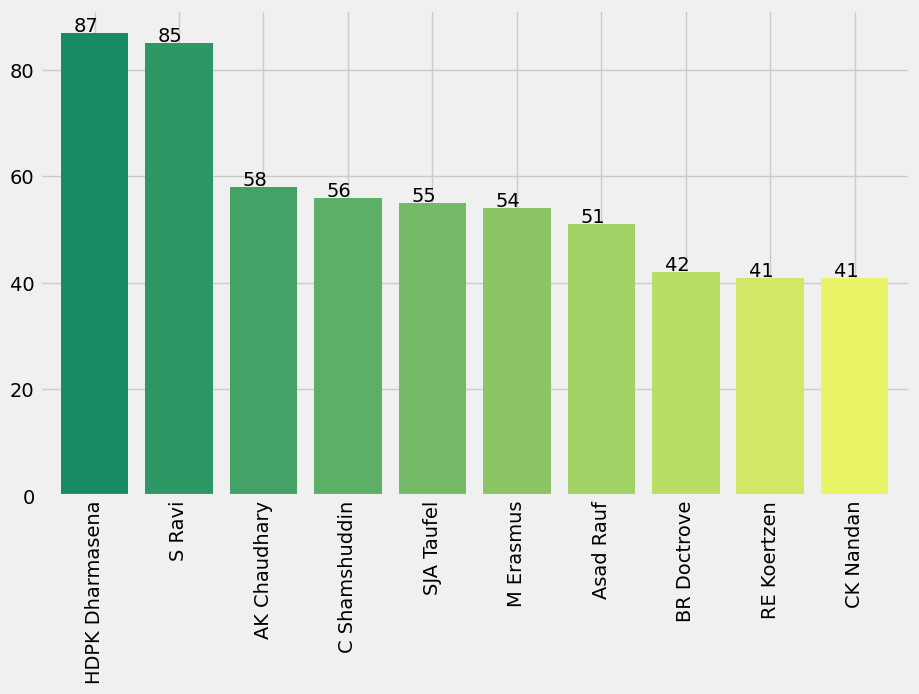

In [8]:
mlt.subplots(figsize = (10, 6))
ump = pd.concat([matches['umpire1'], matches['umpire2']])
ax = ump.value_counts().head(10).plot.bar(width = 0.8, color = sns.color_palette('summer', 10))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.15, p.get_height() + 0.25))
mlt.show()

Team1 vs Team2

MI vs KKR

In [64]:
def team1_vs_team2(team1, team2):
    mt1 = matches[((matches['team1'] == team1) | (matches['team2'] == team1)) & ((matches['team1'] == team2) | (matches['team2'] == team2))]
    sns.countplot(x = 'season', hue = 'winner', data = mt1, palette = 'Set3')
    mlt.xticks(rotation = 'vertical')
    leg = mlt.legend( loc = 'upper center')
    fig = mlt.gcf()
    fig.set_size_inches(10, 6)
    mlt.show()
    

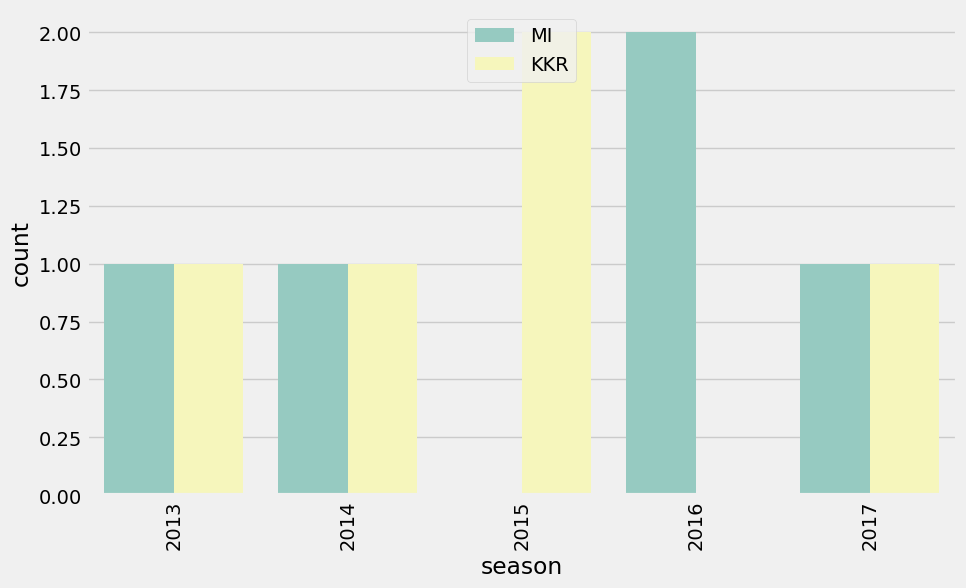

In [65]:
team1_vs_team2('KKR', 'MI')

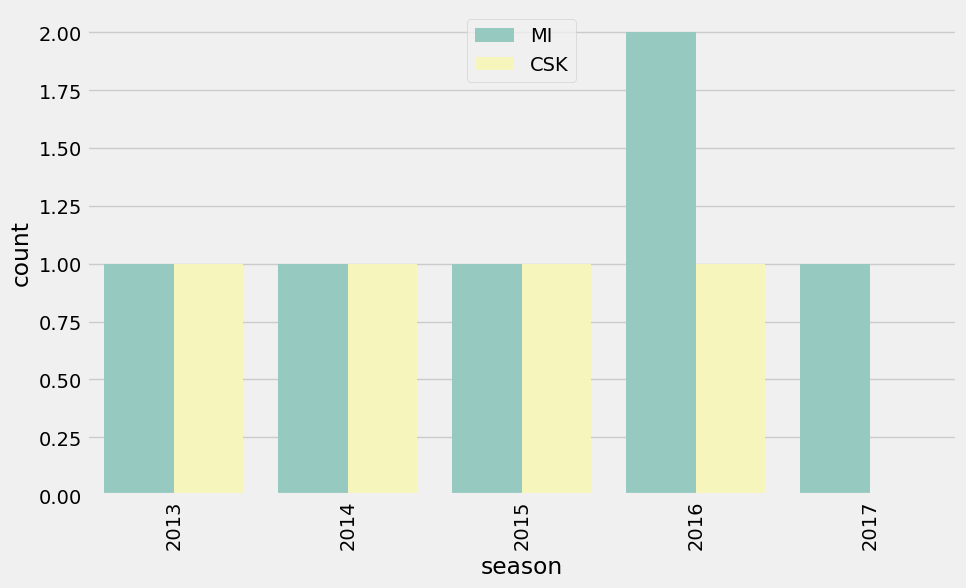

In [68]:
team1_vs_team2('CSK', 'MI')

Matches Won by a Team Against Other Teams

In [48]:
def comparator(team1):
    teams = ['MI', 'KKR', 'RCB', 'DC', 'CSK', 'RR', 'DD', 'GL', 'KXIP', 'SRM', 'RPS', 'KTK', 'PW']
    teams.remove(team1)
    opponents = teams.copy()
    mt1 = matches[((matches['team1'] == team1) | (matches['team2'] == team1))]
    for i in opponents:
        mask = (
            ((mt1['team1'] == i) | (mt1['team2'] == i)) & 
            ((mt1['team1'] == team1) | (mt1['team2'] ==  team1))
        )
        mt2 = mt1.loc[mask, 'winner'].value_counts().to_frame().T
        print(mt2)

In [49]:
print(matches['team1'].unique())

['MI' 'KKR' 'RCB' 'DC' 'CSK' 'RR' 'DD' 'GL' 'KXIP' 'SRM' 'RPS' 'KTK' 'PW']


In [50]:
comparator('KKR')

winner  KKR  MI
count     5   5
winner  KKR  RCB
count     2    2
winner  DC  KKR
count    3    1
winner  KKR  CSK
count    13    8
winner  KKR  RR
count    16   5
winner  KKR  DD
count    11   9
winner  KKR  GL
count    10  10
winner  KKR  KXIP
count    12    10
winner  KKR  SRM
count    10    6
winner  KKR  RPS
count     7    5
winner  KTK
count     1
winner  KKR  PW
count     5   1


Score Distribution for Teams Innings

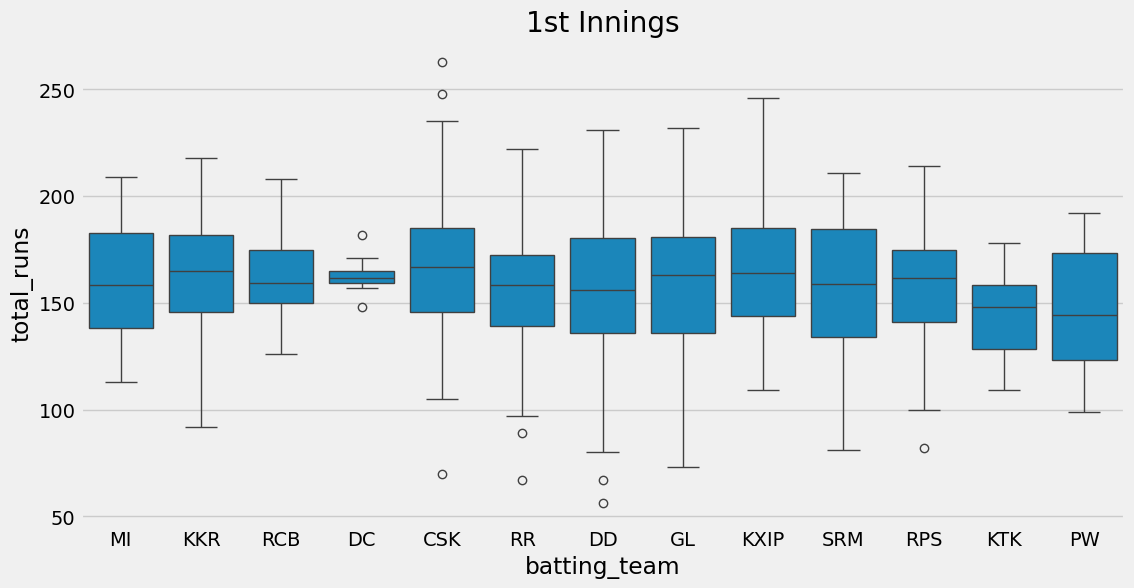

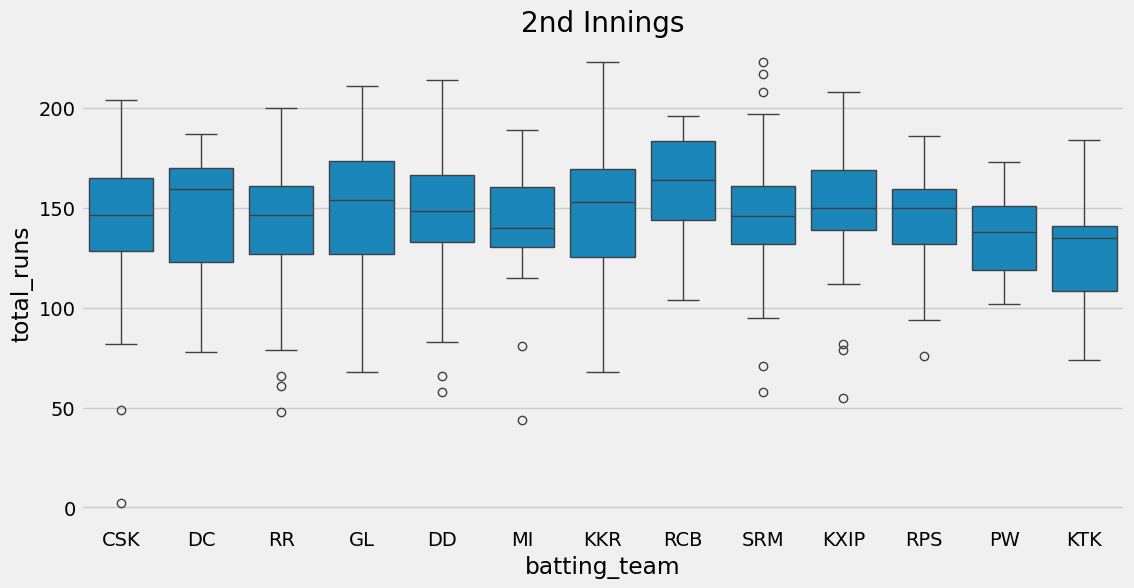

In [115]:
mlt.subplots(figsize = (12, 6))
xyz = deliveries.groupby(['match_id', 'inning', 'batting_team'])['total_runs'].sum().reset_index()
xyz.drop('match_id', axis = 1, inplace = True)
xyz.sort_values(by = ['batting_team', 'total_runs'], ascending = True)
score_1_inning = xyz[xyz['inning'] == 1]
score_2_inning = xyz[xyz['inning'] == 2]
sns.boxplot(x = 'batting_team', y = 'total_runs', data = score_1_inning).set_title('1st Innings')
mlt.show()
sns.boxplot(x = 'batting_team', y = 'total_runs', data = score_2_inning).set_title('2nd Innings')
fig = mlt.gcf()
fig.set_size_inches(12, 6)


200+ Scores

In [30]:
high_scores = deliveries.groupby(['match_id', 'inning', 'batting_team', 'bowling_team'])['total_runs'].sum().reset_index()
high_scores = high_scores[high_scores['total_runs'] >= 200]
high_scores.nlargest(10, 'total_runs')

,match_id,inning,batting_team,bowling_team,total_runs
829,411,1,CSK,PW,263
1250,620,1,CSK,RCB,248
416,206,1,KXIP,SRM,246
122,61,1,KXIP,GL,240
1134,562,1,CSK,KKR,235
596,296,1,GL,CSK,232
522,259,1,DD,GL,231
981,486,1,GL,KXIP,231
100,50,1,GL,KKR,230
1170,580,1,CSK,MI,227


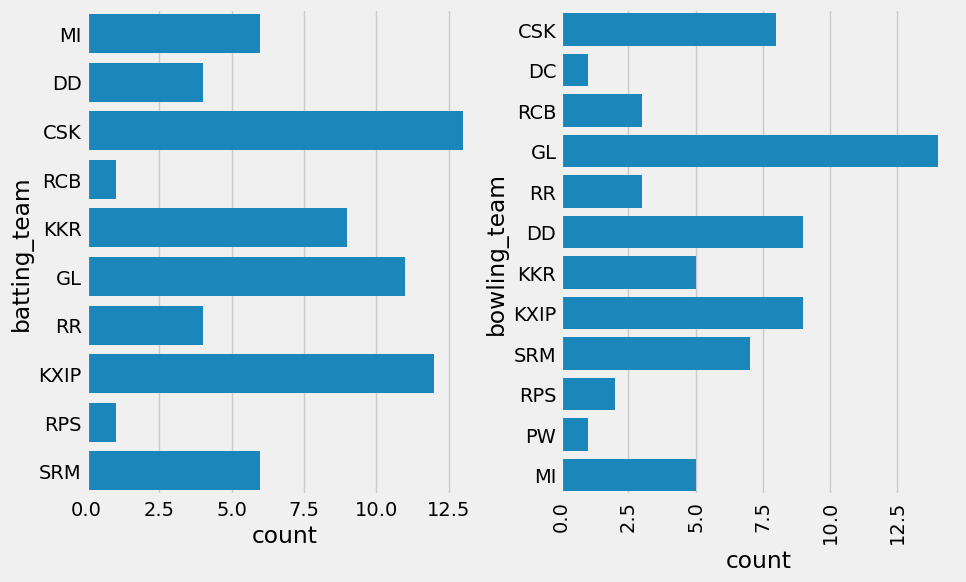

In [119]:
fig, ax = mlt.subplots(1, 2)
sns.countplot(high_scores['batting_team'], ax = ax[0])
sns.countplot(high_scores['bowling_team'], ax = ax[1])
mlt.xticks(rotation = 90)
fig = mlt.gcf()
fig.set_size_inches(10, 6)
mlt.show()


In [140]:
print("Teams who have not ever scored 200+ runs:",list(set(teams) - set(high_scores['batting_team'])))
print("Teams who have not conceeded over 200+ runs:",list(set(teams) - set(high_scores['bowling_team'])))


Teams who have not ever scored 200+ runs: ['PW', 'DC', 'KTK']
Teams who have not conceeded over 200+ runs: ['KTK']


In [142]:
high = deliveries.groupby(['match_id', 'inning', 'batting_team', 'bowling_team'])['total_runs'].sum().reset_index()
high.set_index(['match_id'], inplace = True)
high['total_runs'].max()
high = high.rename(columns = {'total_runs': 'count'})
high = high[high['count'] >= 200].groupby(['inning', 'batting_team', 'bowling_team']).count()
high

count
inning batting_team bowling_team       
1      CSK          DD                1
                    GL                3
                    KKR               1
                    KXIP              1
                    MI                1
                    PW                1
                    RCB               2
                    SRM               1
       DD           DC                1
                    GL                1
                    KKR               1
       GL           CSK               2
                    KKR               1
                    KXIP              2
                    SRM               1
       KKR          CSK               1
                    DD                4
                    KXIP              1
                    SRM               1
       KXIP         CSK               1
                    DD                1
                    GL                2
                    KKR               1
                    MI                2
                    RR                1
                    SRM               1
       MI           CSK               2
                    GL                2
                    RR                1
                    SRM               1
       RCB          DD                1
       RPS          SRM               1
       RR           CSK               1
                    GL                1
                    RPS               1
       SRM          DD                1
                    GL                1
                    KXIP              1
2      CSK          GL                1
                    MI                1
       DD           RCB               1
       GL           DD                1
                    KXIP              2
                    MI                1
                    RR                1
       KKR          GL                1
                    KXIP              1
       KXIP         CSK               1
                    GL                1
                    SRM               1
       RR           GL                1
       SRM          KKR               1
                    KXIP              1
                    RPS               1

In [39]:
high_scores = deliveries.groupby(['match_id', 'inning', 'batting_team', 'bowling_team'])['total_runs'].sum().reset_index()
high_scores1 = high_scores[high_scores['inning'] == 1]
high_scores2 = high_scores[high_scores['inning'] == 2]
high_scores1 =high_scores1.merge(high_scores2[['match_id', 'inning', 'total_runs']], on = 'match_id')

high_scores1 = high_scores1.rename(columns={'inning_x':'inning_1', 'inning_y' : 'inning_2', 'total_runs_x' : 'inning1_runs','total_runs_y': 'inning2_runs'})

high_scores1 =high_scores1[high_scores1['inning1_runs'] >= 200]
high_scores1['is_score_chased'] = 1
high_scores1['is_score_chased'] = np.where(high_scores1['inning1_runs'] <= high_scores1['inning2_runs'],'yes', 'no')
high_scores1.head()
                                           

,match_id,inning_1,batting_team,bowling_team,inning1_runs,inning_2,inning2_runs,is_score_chased
0,1,1,MI,CSK,207,2,172,no
8,9,1,DD,DC,205,2,108,no
19,20,1,CSK,RCB,213,2,192,no
31,32,1,MI,GL,207,2,181,no
35,36,1,MI,RR,209,2,161,no


Chances of Chasing 200+ Target

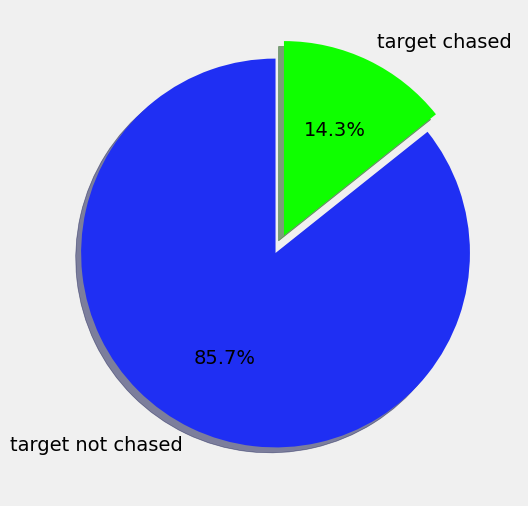

In [47]:
slices = high_scores1['is_score_chased'].map({'yes':1, 'no':0}).value_counts()
labels = ['target not chased', 'target chased']
mlt.pie(slices, labels = labels, colors = ['#1f2ff3', '#0fff00'], startangle = 90, shadow = True, explode = (0, 0.1), autopct = '%1.1f%%')
fig = mlt.gcf()
fig.set_size_inches(6, 6)
mlt.show()

Batsman Comparartor

In [34]:
balls = deliveries.groupby(['batsman'])['ball'].count().reset_index()

In [35]:
runs = deliveries.groupby(['batsman'])['batsman_runs'].sum().reset_index()

In [36]:
balls = balls.merge(runs, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [37]:
balls.rename({"ball": "ball_x", "batsman_runs": "ball_y"}, axis = 1, inplace = True) 

In [38]:
fours = deliveries.groupby('batsman')['batsman_runs'].agg(lambda x: (x == 4).sum()).reset_index()

In [39]:
sixes = deliveries.groupby('batsman')['batsman_runs'].agg(lambda x: (x == 6).sum()).reset_index()

In [40]:
balls['strike_rate'] = balls["ball_y"] / balls["ball_x"] * 100

In [41]:
balls = balls.merge(sixes, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [42]:
balls = balls.merge(fours, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [43]:
compare = deliveries.groupby(['match_id', 'batsman', 'batting_team'])['batsman_runs'].sum().reset_index()

In [44]:
compare = compare.groupby(['batsman', 'batting_team'])['batsman_runs'].max().reset_index()

In [45]:
balls = balls.merge(compare, left_on = 'batsman', right_on = 'batsman', how = 'outer')

In [46]:
balls.rename({'ball_x': 'balls', 'ball_y': 'runs', 'batsman_runs_x': '6''s', 'batsman_runs_y': '4''s', 'batting_team': 'Team', 'batsman_runs': 'Highest_score'}, axis = 1, inplace = True)

In [47]:
balls.head()

,batsman,balls,runs,strike_rate,6s,4s,Team,Highest_score
0,A Ashish Reddy,196,280,142.857143,15,16,Deccan Chargers,10
1,A Ashish Reddy,196,280,142.857143,15,16,Sunrisers Hyderabad,36
2,A Chandila,7,4,57.142857,0,0,Rajasthan Royals,4
3,A Chopra,75,53,70.666667,0,7,Kolkata Knight Riders,24
4,A Choudhary,20,25,125.000000,1,1,Royal Challengers Bangalore,15


In [88]:
balls.tail()

,batsman,balls,runs,strike_rate,6s,4s,Team,Highest_score
783,Yuvraj Singh,2050,2591,126.390244,141,205,MI,70
784,Yuvraj Singh,2050,2591,126.390244,141,205,PW,66
785,Z Khan,141,117,82.978723,2,11,CSK,21
786,Z Khan,141,117,82.978723,2,11,DD,4
787,Z Khan,141,117,82.978723,2,11,KKR,23


In [28]:
balls

,batsman,balls,runs,strike_rate,6s,4s,Team,Highest_score
0,A Ashish Reddy,196,280,142.857143,15,16,Deccan Chargers,10
1,A Ashish Reddy,196,280,142.857143,15,16,Sunrisers Hyderabad,36
2,A Chandila,7,4,57.142857,0,0,Rajasthan Royals,4
3,A Chopra,75,53,70.666667,0,7,Kolkata Knight Riders,24
4,A Choudhary,20,25,125.000000,1,1,Royal Challengers Bangalore,15
...,...,...,...,...,...,...,...,...
785,Yuvraj Singh,2050,2591,126.390244,141,205,Royal Challengers Bangalore,83
786,Yuvraj Singh,2050,2591,126.390244,141,205,Sunrisers Hyderabad,70
787,Z Khan,141,117,82.978723,2,11,Delhi Daredevils,4
788,Z Khan,141,117,82.978723,2,11,Mumbai Indians,23


Batsman Comparator

In [51]:
def batsman_comparator(stat1, stat2, batsman1, batsman2):
    sns.FacetGrid(balls, hue = 'Team', height = 8).map(mlt.scatter, stat1, stat2, alpha = 0.5).add_legend()

    bats1 = balls[balls['batsman'].str.contains(batsman1)].sort_values(by = stat1, ascending = False)
    bats2 = balls[balls['batsman'].str.contains(batsman2)].sort_values(by = stat1, ascending = False)

    mlt.scatter(bats2[stat1], bats2[stat2], s = 75, c = '#f73545')
    mlt.text(x = bats1[stat1].values[0], y = bats1[stat2].values[0], s = batsman1,
             fontsize  = 10, weight = 'bold', color = '#ff58fd')
    mlt.gcf().set_size_inches(15, 10)
    mlt.title('Batsman Comparator', size = 25)
    mlt.show()

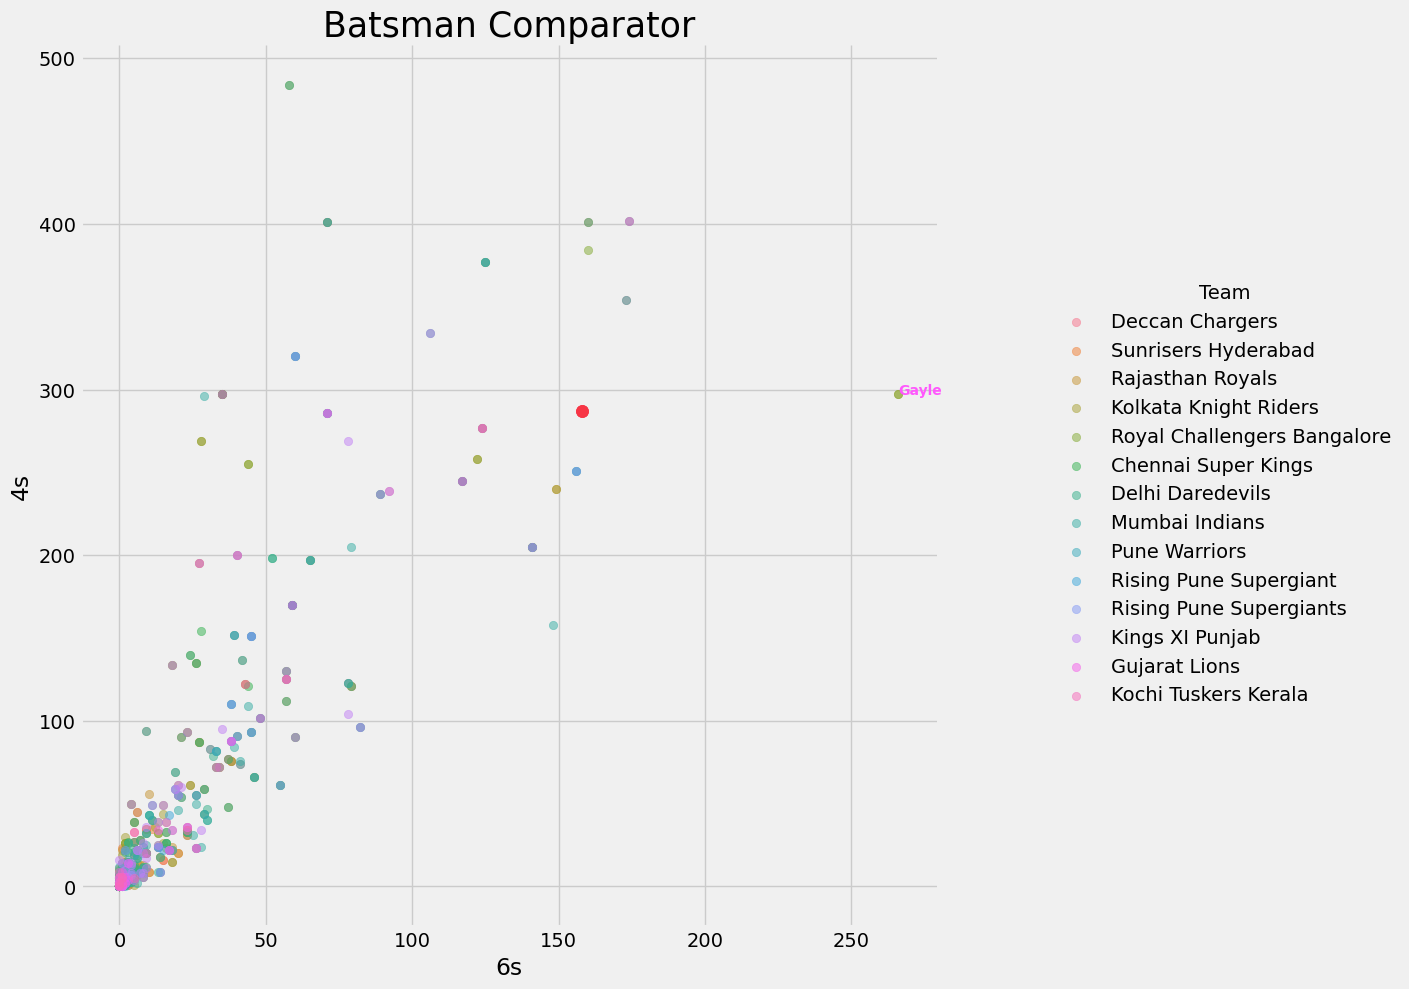

In [52]:
batsman_comparator('6''s', '4''s', 'Gayle', 'Villiers')

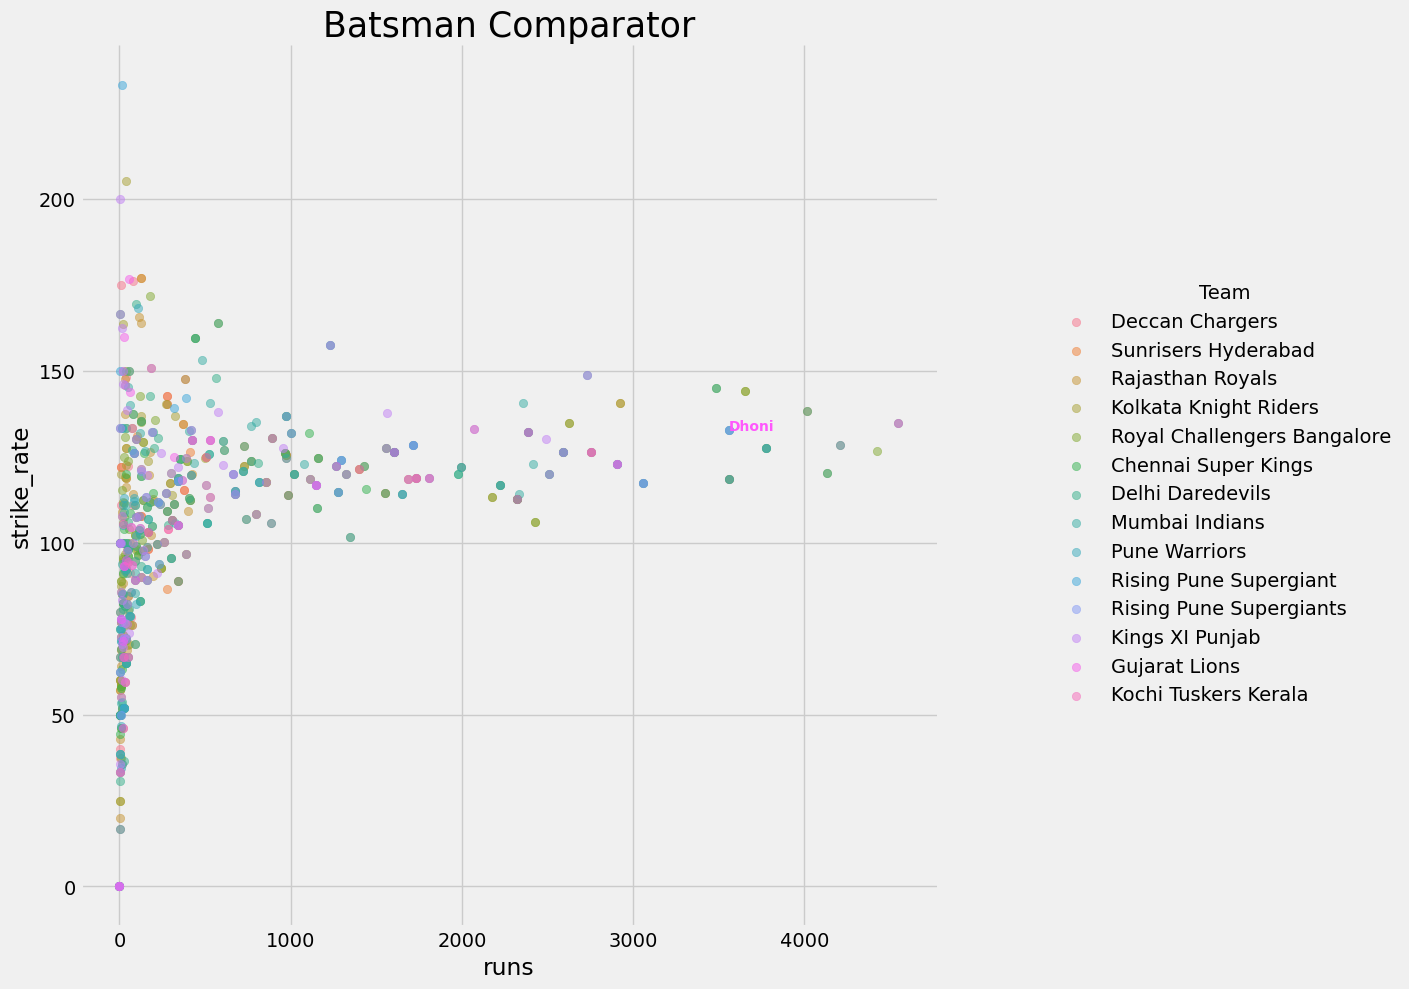

In [47]:
batsman_comparator('runs', 'strike_rate', 'Dhoni', 'V Kholi')

Top Batsman

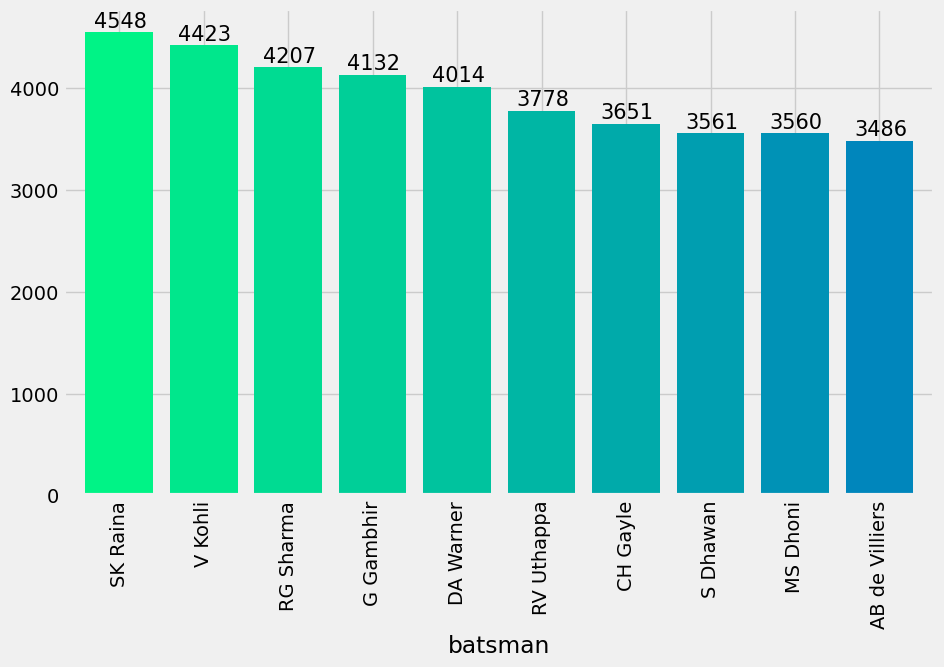

In [65]:
mlt.subplots(figsize = (10, 6))
max_runs = deliveries.groupby(['batsman'])['batsman_runs'].sum()
ax = max_runs = max_runs.sort_values(ascending = False)[:10].plot.bar(width = 0.8, color = sns.color_palette('winter_r', 20))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.1, p.get_height() + 50), fontsize = 15)
mlt.show()


Top Batsman's with 1's, 2's, 3's, 4's

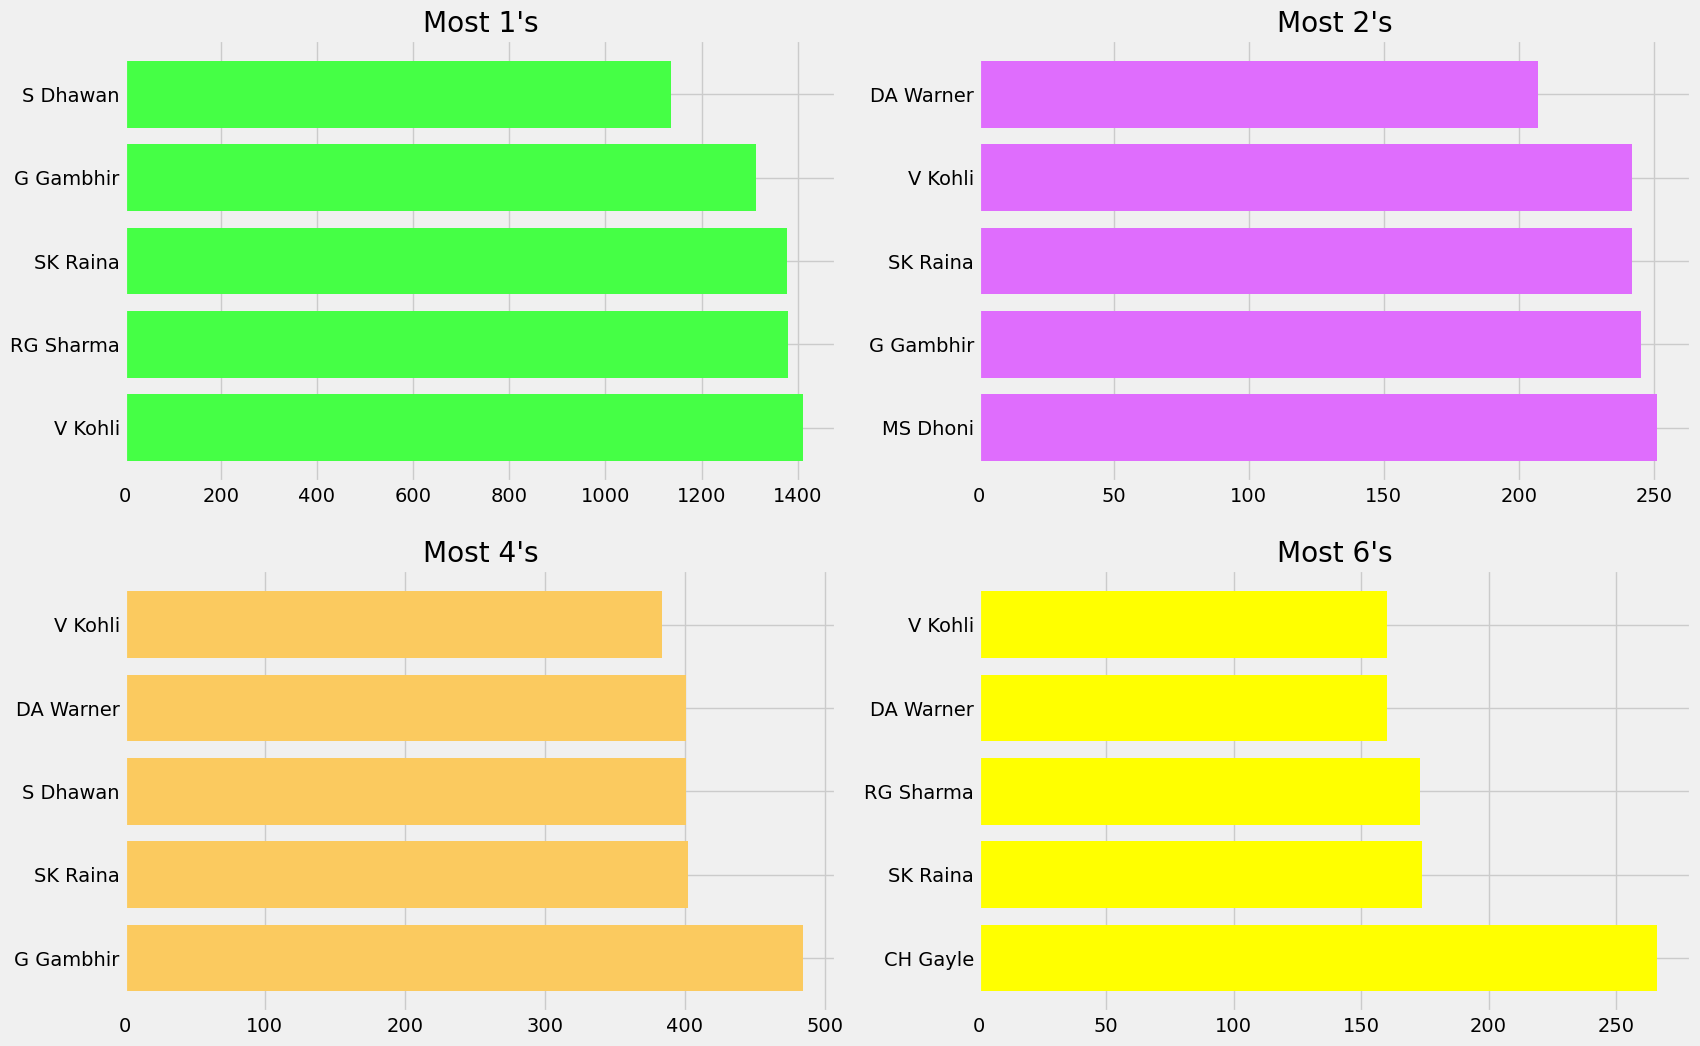

In [75]:
toppers = deliveries.groupby(['batsman', 'batsman_runs'])['total_runs'].count().reset_index()
toppers = toppers.pivot_table(index = 'batsman', columns = 'batsman_runs', values = 'total_runs', fill_value = 0)
fig, ax = mlt.subplots(2,2,
figsize = (18, 12))

toppers[1].sort_values(ascending = False)[:5].plot.barh(ax = ax[0,0], color = '#45ff45', width = 0.8)
ax[0,0].set_title("Most 1's")
ax[0,0].set_ylabel('')

toppers[2].sort_values(ascending = False)[:5].plot.barh(ax = ax[0,1], color = '#df6dfd', width = 0.8)
ax[0,1].set_title("Most 2's")
ax[0,1].set_ylabel('')

toppers[4].sort_values(ascending = False)[:5].plot.barh(ax = ax[1,0], color = '#fbca5f', width = 0.8)
ax[1,0].set_title("Most 4's")
ax[1,0].set_ylabel('')

toppers[6].sort_values(ascending = False)[:5].plot.barh(ax = ax[1,1], color = '#ffff00', width = 0.8)
ax[1,1].set_title("Most 6's")
ax[1,1].set_ylabel('')

mlt.show()


Top Individual Scores

In [79]:
top_scores = deliveries.groupby(['match_id', 'batsman', 'batting_team'])['batsman_runs'].sum().reset_index()
top_scores.sort_values('batsman_runs', ascending = 0).head(10)
top_scores.nlargest(10, 'batsman_runs')

,match_id,batsman,batting_team,batsman_runs
6200,411,CH Gayle,CSK,175
900,60,BB McCullum,RR,158
8426,562,AB de Villiers,CSK,133
9257,620,AB de Villiers,CSK,129
5585,372,CH Gayle,CSK,128
3135,206,M Vijay,KXIP,127
529,36,DA Warner,MI,126
7752,516,V Sehwag,GL,122
3686,243,PC Valthaty,GL,120
4223,279,V Sehwag,DD,119


Individual Scores by Top Batsman each Inning

In [82]:
import warnings
warnings.filterwarnings('ignore')

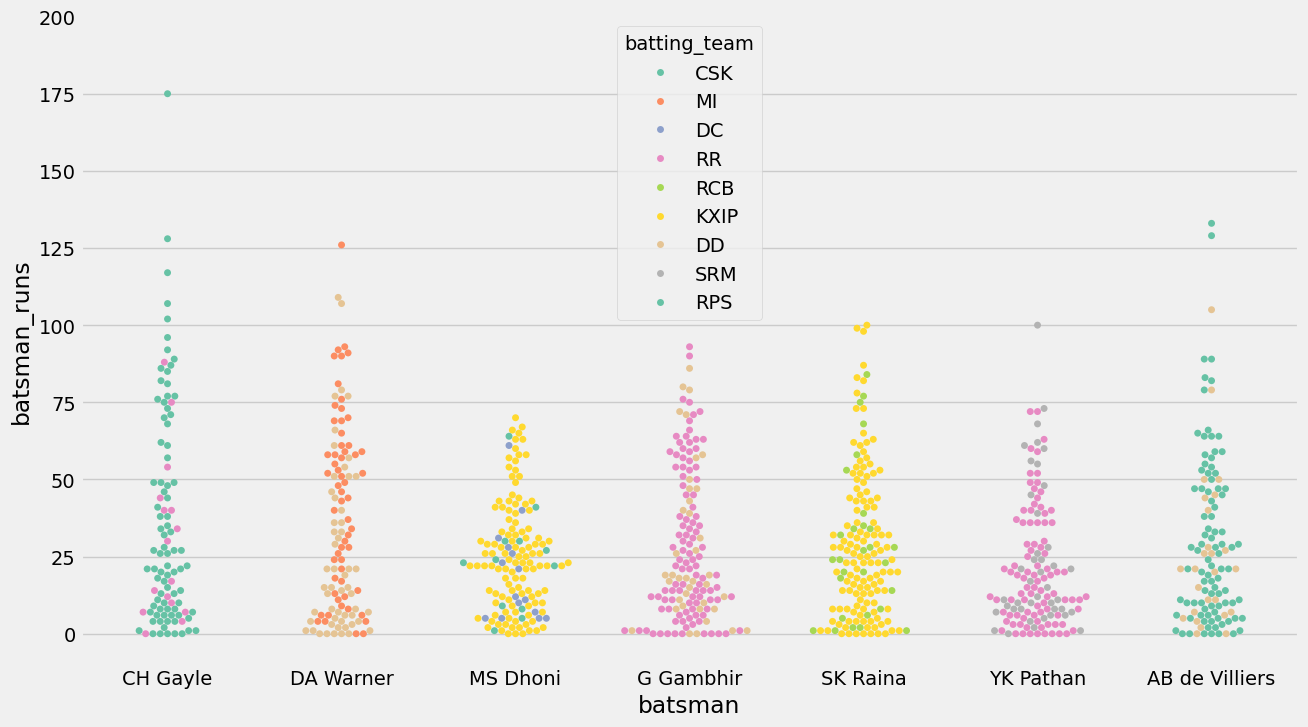

In [85]:
swarm = ['CH Gayle', 'V Kholi', 'G Gambhir', 'SK Raina', 'YK Pathan', 'MS Dhoni', 'AB de Villiers', 'DA Warner']
scores = deliveries.groupby(['match_id', 'batsman', 'batting_team'])['batsman_runs'].sum().reset_index()
scores = scores[top_scores['batsman'].isin(swarm)]
sns.swarmplot(x = 'batsman', y = 'batsman_runs', data = scores,
              hue = 'batting_team',
              palette = 'Set2')
fig = mlt.gcf()
fig.set_size_inches(14, 8)
mlt.ylim(-10, 200)
mlt.show()

Runs Scored by Batsman Across Season

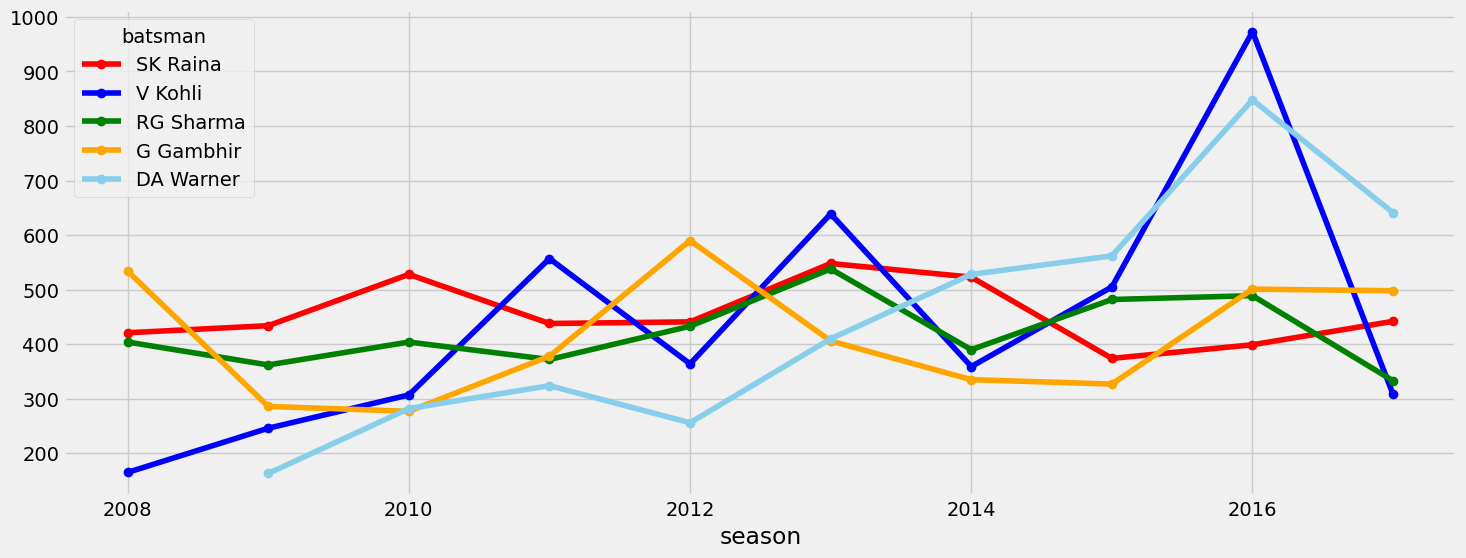

In [132]:
a = batsmen.groupby(['season', 'batsman'])['batsman_runs'].sum().reset_index()
a = a.groupby(['season', 'batsman'])['batsman_runs'].sum().unstack().T
a['Total'] = a.sum(axis = 1)
a = a.sort_values(by = 'Total', ascending = 0).head(5)
a.drop('Total', axis = 1, inplace = True)
a.T.plot(color = ['red', 'blue', 'green', 'orange', 'skyblue'], marker = 'o')
fig = mlt.gcf()
fig.set_size_inches(16, 6)
mlt.show()

Frequency of Scores

In [115]:
top_scores.head()

,match_id,batsman,batting_team,batsman_runs
0,1,A Choudhary,CSK,6
1,1,BCJ Cutting,MI,16
2,1,CH Gayle,CSK,32
3,1,DA Warner,MI,14
4,1,DJ Hooda,MI,16


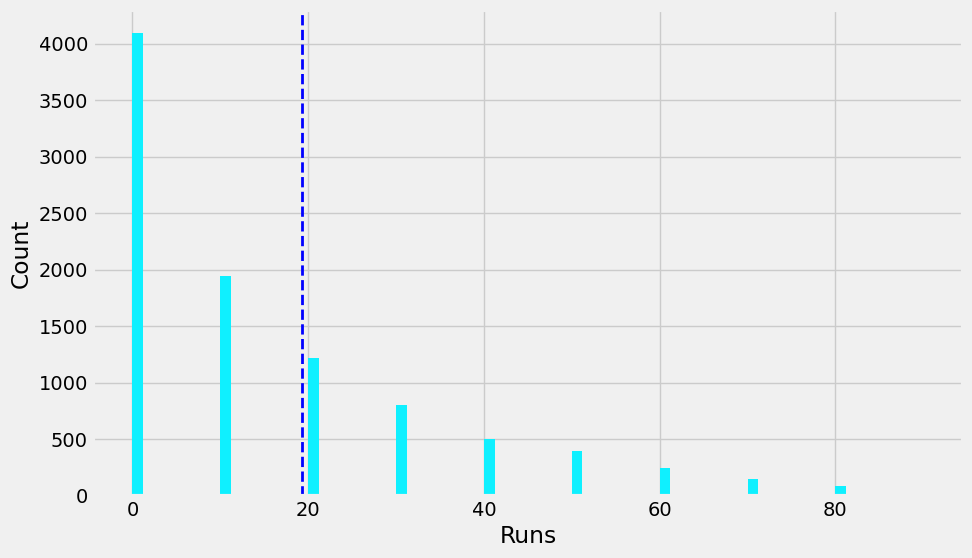

In [112]:
mlt.subplots(figsize = (10, 6))
bins = range(0, 100, 10)
mlt.hist(top_scores['batsman_runs'], bins, histtype = 'bar', width = 1.2, color = '#0ff0ff')
mlt.xlabel('Runs')
mlt.ylabel('Count')
mlt.axvline(top_scores['batsman_runs'].mean(), color = 'b', linestyle = 'dashed', linewidth = 2)
mlt.plot()
mlt.show()


Orange Caps each Season (Highest Run better Per Season)

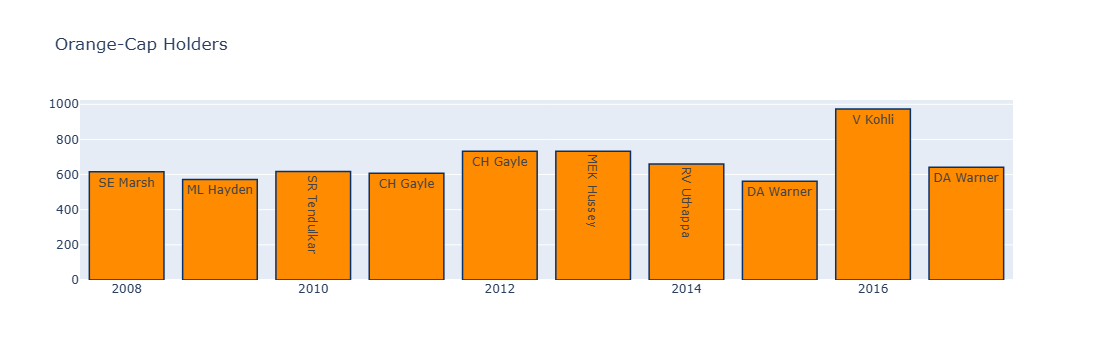

In [110]:
orange = matches[['id', 'season']]
orange = orange.merge(deliveries, left_on = 'id', right_on = 'match_id', how = 'left')
orange = orange.groupby(['season', 'batsman'])['batsman_runs'].sum().reset_index()
orange = orange.sort_values('batsman_runs', ascending = 0)
orange = orange.drop_duplicates(subset = ['season'], keep = 'first')
orange = orange.sort_values(by = 'season')
trace1 = go.Bar(
x = orange['season'].values,
y = orange['batsman_runs'].values,
name = 'Total Matches',
text = orange['batsman'].values,
marker = dict(
color = 'rgb(255, 140, 0)',
line = dict(
color = 'rgb(8, 48, 107)',
width = 1.5,
)
),
opacity = 1
)
layout = go.Layout(
title = 'Orange-Cap Holders',
)
data = [trace1]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig, filename = 'stacked-bar')

Top Bowlers

Highest Wicket Taker

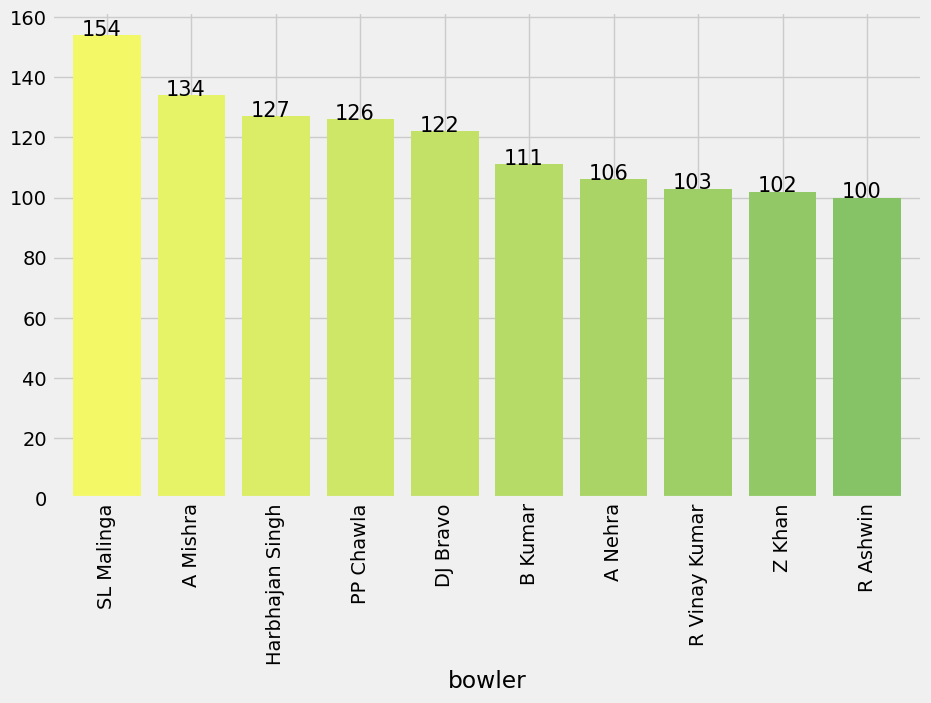

In [14]:
mlt.subplots(figsize = (10, 6))
dismissal_kinds = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
ct = deliveries[deliveries['dismissal_kind'].isin(dismissal_kinds)]
ax = ct['bowler'].value_counts()[:10].plot.bar(width = 0.8, color = sns.color_palette('summer_r', 20))
for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.10, p.get_height()), fontsize = 15)
mlt.show()

Maximum Overs

In [19]:
eco = deliveries.groupby(['bowler']).sum(numeric_only = True)
eco['total balls'] = deliveries['bowler'].value_counts()
eco['overs'] = (eco['total balls']//6)
eco[eco['overs'] > 200].sort_values(by = 'overs', ascending = 0)['overs'].head(5).reset_index()

,bowler,overs
0,Harbhajan Singh,498
1,A Mishra,450
2,SL Malinga,449
3,P Kumar,439
4,PP Chawla,432


In [49]:
eco['economy'] = (eco['total_runs'] / (eco['overs']))
eco[eco['overs'] > 300].sort_values('economy')[:10].economy.reset_index().T

,0,1,2,3,4,5,6,7,8,9
bowler,SP Narine,R Ashwin,DW Steyn,SL Malinga,Harbhajan Singh,B Kumar,A Mishra,PP Ojha,Z Khan,P Kumar
economy,6.395706,6.493639,6.615599,6.757238,6.933735,7.046784,7.344444,7.404321,7.546174,7.612756


Top 20 Bowlers

In [50]:
bowlers = deliveries.groupby('bowler').sum(numeric_only = True).reset_index()

In [51]:
bowl = deliveries['bowler'].value_counts().reset_index()
bowl.columns = ['bowler', 'balls']
bowl['index'] = range(1, len(bowl) + 1)

bowl['bowler'] = bowl['bowler'].astype(str)
bowlers['bowler'] = bowlers['bowler'].astype(str)

bowlers = bowlers.merge(bowl, on = 'bowler', how = 'left')
bowlers = bowlers[['bowler', 'total_runs', 'balls']]
bowlers.rename({'total_runs': 'runs_given'}, axis =1, inplace = True)
bowlers['overs'] = bowlers['balls']//6

dismissal_kinds = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
ct = deliveries[deliveries['dismissal_kind'].isin(dismissal_kinds)]
ct = ct['bowler'].value_counts()[:20].reset_index()
ct.columns = ['bowler', 'wickets']
ct['bowler'] = ct['bowler'].astype(str)

bowlers = bowlers.merge(ct, on = 'bowler', how = 'left').dropna()
bowlers['economy'] = bowlers['runs_given'] / bowlers['overs']
bowlers.head()
    

,bowler,runs_given,balls,overs,wickets,economy
5,A Mishra,3305,2703,450,134.0,7.344444
7,A Nehra,2537,1974,329,106.0,7.711246
50,B Kumar,2410,2054,342,111.0,7.046784
88,DJ Bravo,2815,2110,351,122.0,8.019943
103,DW Steyn,2375,2159,359,92.0,6.615599


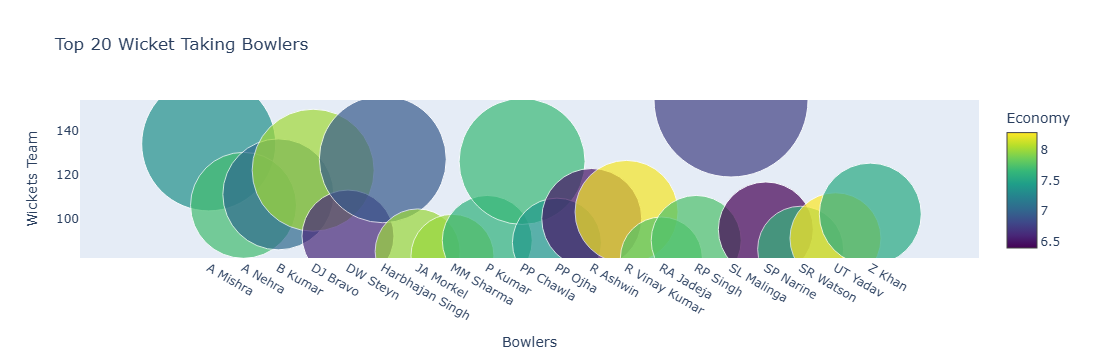

In [61]:
trace = go.Scatter(
y = bowlers['wickets'],
x = bowlers['bowler'],
mode = 'markers',
marker = dict(
size = bowlers['wickets'].values,
    color = bowlers['economy'].values,
    colorscale = 'Viridis',
    showscale = True,
    colorbar = dict(title = 'Economy'),
),
text = bowlers['overs'].values
)
data = [(trace)]
layout = go.Layout(
    autosize = True,
    title = 'Top 20 Wicket Taking Bowlers',
    hovermode = 'closest',
    xaxis = dict(
    showgrid = False,
        zeroline = False,
        showline = False,
        title = 'Bowlers' 
    ),
    yaxis = dict(
    title = 'Wickets Team',
        ticklen = 5,
        gridwidth = 2,
        showgrid = False,
        zeroline = False, 
        showline = False
    ),
    showlegend = False
)
fig = go.Figure(data = data, layout = layout)
py.iplot(fig, filename = 'scatterChol')
    

Highest Dismissals for a Batsman by a Bowler 

In [9]:
def get_top_bowler(batsman_name):
    batsman_data = deliveries[deliveries['batsman'] == batsman_name]
    batsman_data = batsman_data[batsman_data['dismissal_kind'].isin(['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket'])]
    top_bowler = batsman_data.groupby('bowler').count().sort_values(by = 'dismissal_kind', ascending = False).dismissal_kind[:1].reset_index()
    top_bowler['batsman'] = batsman_name
    return top_bowler

In [10]:
batsman = ['CH Gayle', 'V Kholi', 'G Gambhir', 'SK Raina', 'YK Pathan', 'MS Dhoni', 'AB de Villiers', 'DA Warner', 'RG Sharma', 'S Dhawan', 'RV Uthappa']

In [11]:
results = [get_top_bowler(batsman) for batsman in batsman]

In [12]:
new = pd.concat(results, ignore_index = True)
new = new[['batsman', 'bowler', 'dismissal_kind']]
new.columns = ['batsman', 'bowler', 'No_of_Dismissals']

In [13]:
new.head()

,batsman,bowler,No_of_Dismissals
0,CH Gayle,R Ashwin,4
1,G Gambhir,Z Khan,6
2,SK Raina,Harbhajan Singh,5
3,YK Pathan,R Vinay Kumar,4
4,MS Dhoni,Z Khan,7


Purple Caps each Season

In [6]:
dismissal_kinds = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
purple = deliveries[deliveries['dismissal_kind'].isin(dismissal_kinds)]
purple = deliveries.merge(matches, left_on = 'match_id', right_on = 'id', how = 'outer')


In [7]:
purple = purple.groupby(['season', 'bowler'])['dismissal_kind'].count().reset_index()

In [8]:
purple = purple.sort_values('dismissal_kind', ascending = False)

In [116]:
purple = purple.drop_duplicates('season', keep = 'first').sort_values(by = 'season')

In [120]:
purple.rename({'dismissal_kind': 'count_wickets'}, axis = 1, inplace = True)

In [121]:
purple

,season,bowler,count_wickets
84,2008,Sohail Tanvir,24
174,2009,RP Singh,26
284,2010,PP Ojha,22
447,2011,SL Malinga,30
537,2012,M Morkel,30
629,2013,DJ Bravo,34
780,2014,MM Sharma,26
848,2015,DJ Bravo,28
939,2016,B Kumar,24
1049,2017,B Kumar,28


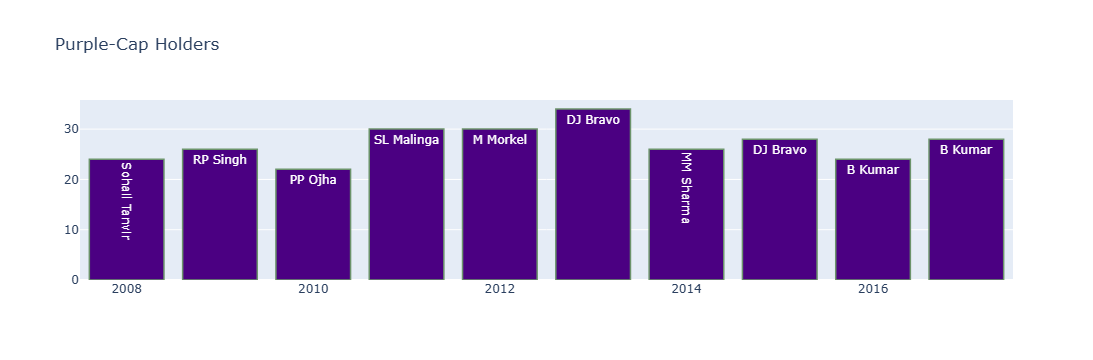

In [124]:
trace1 = go.Bar(
x = purple['season'].values,
y = purple['count_wickets'].values,
name = 'Total Matches',
text = purple['bowler'].values,
marker = dict(
    color = 'rgb(75, 0, 130)',
    line = dict(
        color = 'rgb(108, 148, 107)',
        width = 1.5
    )
),
    opacity = 1
)
layout = go.Layout(
    title = 'Purple-Cap Holders',
)
data = [trace1]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig, filename = 'stacked-bar')